In [1]:
# Project root setup
import os
import sys
from pathlib import Path

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the project root containing src/.")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Different variances - Nonnegative CoLiDE

Replica of `synthetic/notebooks/different_vars.ipynb` for the nonnegative version of CoLiDE
(SCA+Adam, NV and EV) against NOMAD, DAGMA and CoLiDE (EV and NV). The noise variance sweeps
`[1, 5, 10, 15, 20, 25, 30]` under two scenarios run sequentially:

- **homoscedastic**: every node has variance `var`;
- **heteroscedastic**: per-node profile `sigma_j^2` with `sigma_j ~ U(0.5, 5)`, scaled by `var`.

The notebook imports `experiments/scripts/different_vars.py`, which holds all the experiment code and takes
the methods and hyperparameters from `experiments/scripts/number_samples.py`, so both experiments share
the same baselines.

- `LOAD = True` (default): loads the results saved in `results/var/` and plots them.
- `LOAD = False`: runs the experiment from the notebook (long). To run it in the background use instead:

```
nohup .venv-dag/bin/python experiments/scripts/different_vars.py > logs/salida_nonneg_colide_vars.txt 2>&1 &
```

Metrics: normalized SHD (SHD / N), normalized Frobenius error of W and, for the methods that estimate Sigma,
the Sigma error computed after normalizing both vectors (same criterion as the error of W).

In [2]:
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.utils as utils
import experiments.scripts.different_vars as dv

# Reload so notebook changes pick up the latest script version and current baselines.
dv = importlib.reload(dv)

## Controls

In [3]:
# Notebook controls. These override the defaults in experiments/scripts/different_vars.py.
LOAD = True            # Set to False to rerun from the notebook.
SAVE = False           # Save npz/csv when running from the notebook.
SAVE_FIGS = False      # Save the figures next to the results.
RESULTS_DIR = None     # None -> results/var/ ; e.g. "results/var_smoke/"

N_DAGS = dv.N_DAGS
THR = dv.THR
VERB = dv.VERB
VAR_VALUES = dv.VAR_VALUES
BASE_DATA_PARAMS = dv.BASE_DATA_PARAMS.copy()
JOINT_AGGS = dv.JOINT_AGGS
SKIP_IDX = []          # Method indices to hide in every figure, e.g. [3] hides DAGMA.

# Push notebook controls back into the script module used below.
dv.LOAD = LOAD
dv.SAVE = SAVE
if RESULTS_DIR is not None:
    dv.PATH = str(ROOT / RESULTS_DIR) + os.sep
os.makedirs(dv.PATH, exist_ok=True)
print("Results folder:", dv.PATH)

Results folder: /home/srey/Investigacion/nonneg_dag_learning/nomad/results/nonneg_colide/var/


In [4]:
Exps = dv.build_experiments()
var_values = np.asarray(VAR_VALUES)
scenarios = dv.build_scenarios(BASE_DATA_PARAMS)
hom_scenario, hetero_scenario = scenarios

print("Scenarios:", [scenario["name"] for scenario in scenarios])
print("Methods:")
for i, exp in enumerate(Exps):
    skipped = " (skipped)" if i in SKIP_IDX else ""
    print(f"  {i}: {exp['leg']}{skipped}")
print("Variance grid:", var_values)
print("Mode:", "load" if LOAD else "run")

pd.DataFrame([{"leg": e["leg"], "model": e["model"].__name__, "sigma": e["sigma"], "adapt_lamb": e["adapt_lamb"],
               **e.get("init", {}), **e["args"]} for e in Exps]).set_index("leg")

Scenarios: ['homoscedastic', 'heteroscedastic']
Methods:
  0: NN-CoLiDE-NV
  1: NN-CoLiDE-EV
  2: NOMAD-adam
  3: DAGMA
  4: CoLiDE-EV
  5: CoLiDE-NV
Variance grid: [ 1  5 10 15 20 25 30]
Mode: load


,model,sigma,adapt_lamb,primal_opt,acyclicity,equal_var,stepsize,step_type,alpha_0,rho_0,...,iters_in,iters_out,beta,sca_adam,loss_type,lambda1,T,warm_iter,max_iter,lr
leg,,,,,,,,,,,,,,,,,,,,,
NN-CoLiDE-NV,MetMulColide,True,True,sca,logdet,False,0.0003,fixed,0.01,0.05,...,30000.0,10.0,2.0,True,NaN,NaN,NaN,NaN,NaN,NaN
NN-CoLiDE-EV,MetMulColide,True,True,sca,logdet,True,0.0003,fixed,0.01,0.05,...,30000.0,10.0,2.0,True,NaN,NaN,NaN,NaN,NaN,NaN
NOMAD-adam,MetMulDagma,False,True,adam,logdet,NaN,0.0050,fixed,0.10,0.10,...,5000.0,10.0,1.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DAGMA,DAGMA_linear,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,l2,0.05,4.0,20000.0,70000.0,0.0003
CoLiDE-EV,colide_ev,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.05,4.0,20000.0,70000.0,0.0003
CoLiDE-NV,colide_nv,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.05,4.0,20000.0,70000.0,0.0003


## Plotting helpers

In [5]:
def scenario_result(scenario, metrics, exps, var_values):
    return {"scenario": scenario, "metrics": metrics, "exps": exps, "var_values": var_values}


def show_tables(metrics, exps, var_values, title):
    m = dict(zip(dv.METRIC_NAMES, metrics))
    legs = [e["leg"] for e in exps]
    for metric, agg, label in [("shd", np.mean, "normalized SHD (mean)"), ("err", np.median, "Fro error (median)"),
                               ("err_sig", np.nanmedian, "Sigma error (median)"), ("runtime", np.mean, "time (mean, s)")]:
        table = pd.DataFrame(agg(m[metric], axis=0), index=var_values, columns=legs).rename_axis("variance")
        print(f"\n{title} - {label}")
        display(table.round(4))


def show_scenario(scenario, skip_idx=()):
    *metrics, exps, xvals = dv.run_or_load_vars_results(scenario, var_values, Exps, N_DAGS, thr=THR, verb=VERB)
    dv.plot_results(metrics, exps, xvals, scenario["suffix"], skip_idx=list(skip_idx), save=SAVE_FIGS)
    plt.show()
    show_tables(metrics, exps, xvals, scenario["name"])
    return scenario_result(scenario, metrics, exps, xvals)

## Homoscedastic scenario

[2026-09-15T09:23:31 pid=57112] Loaded variance results from /home/srey/Investigacion/nonneg_dag_learning/nomad/results/nonneg_colide/var/var_hom_ERgraph_4N.npz


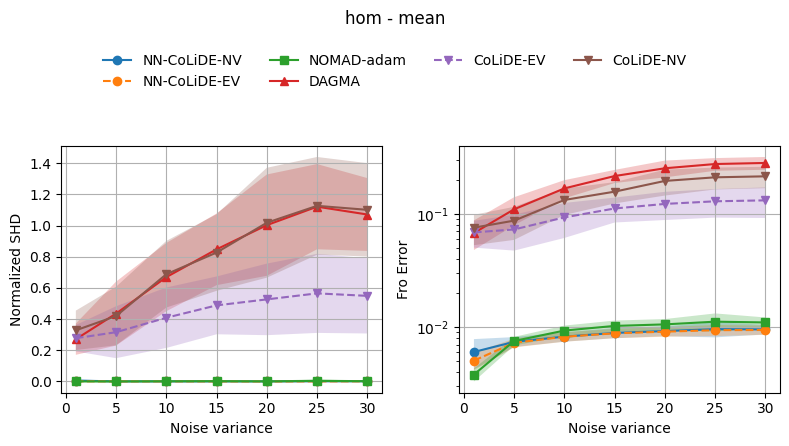

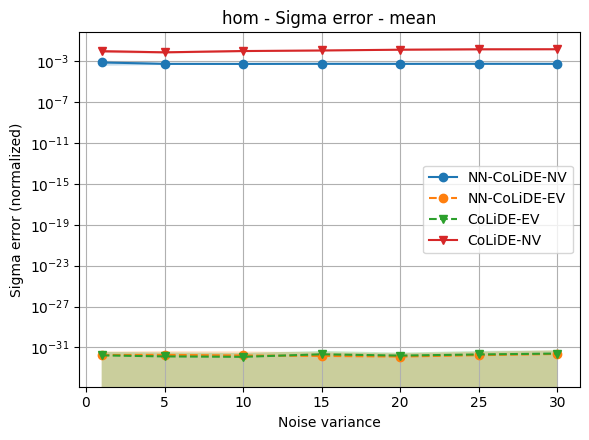

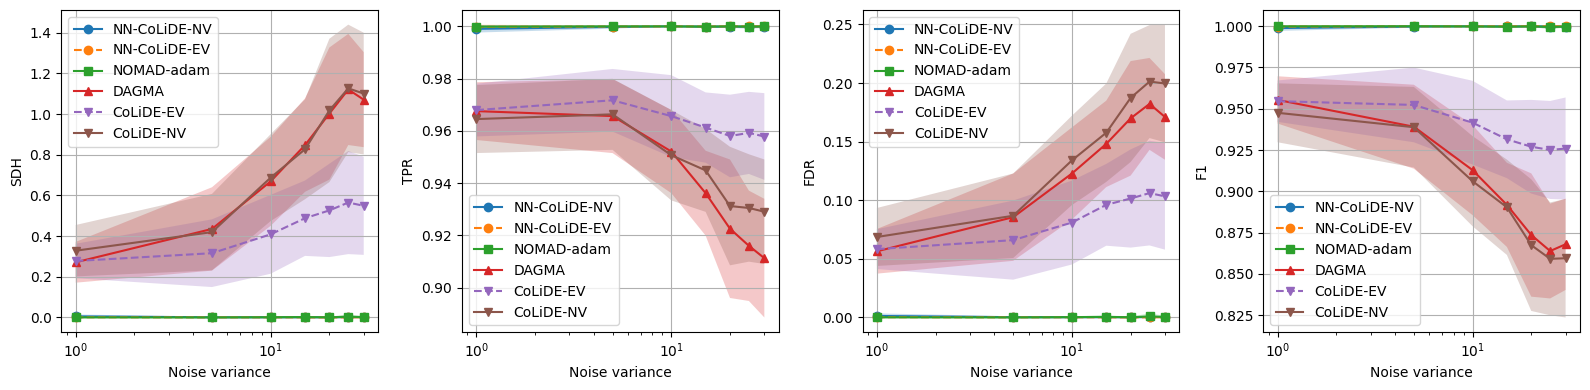

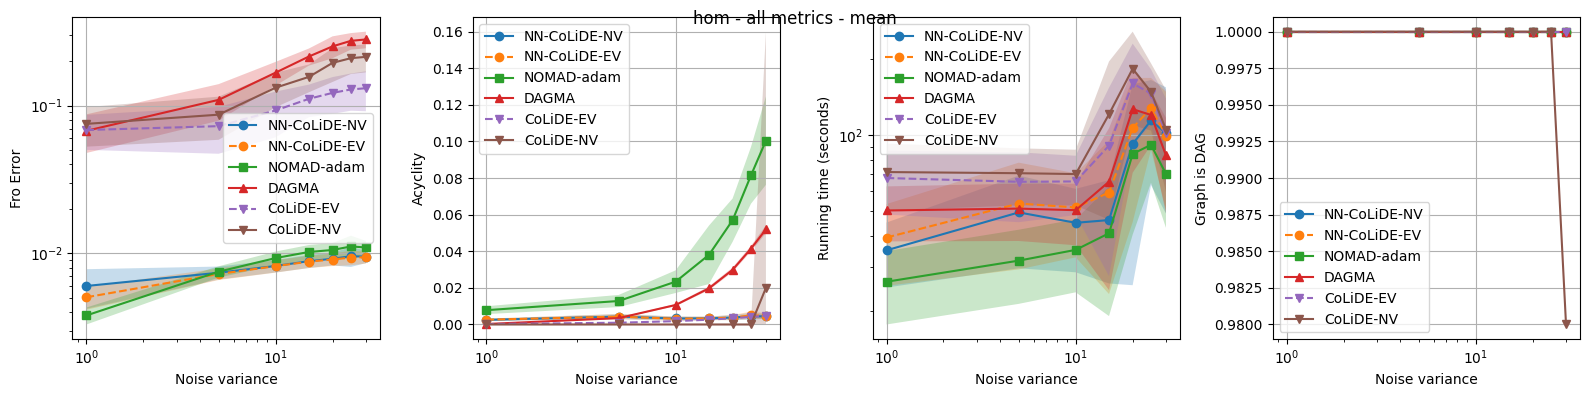

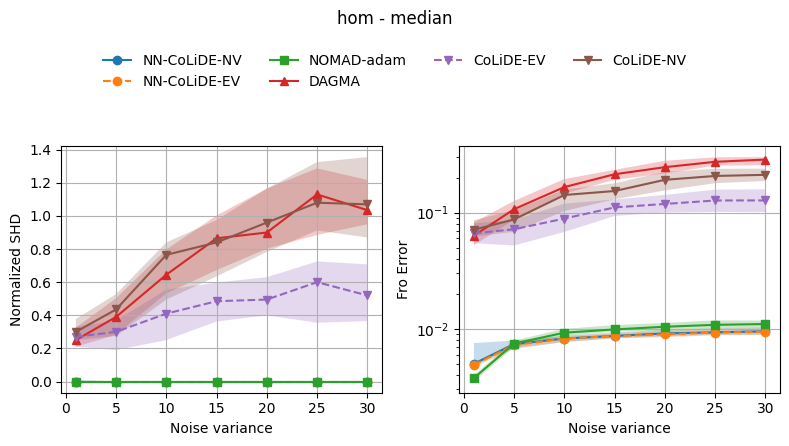

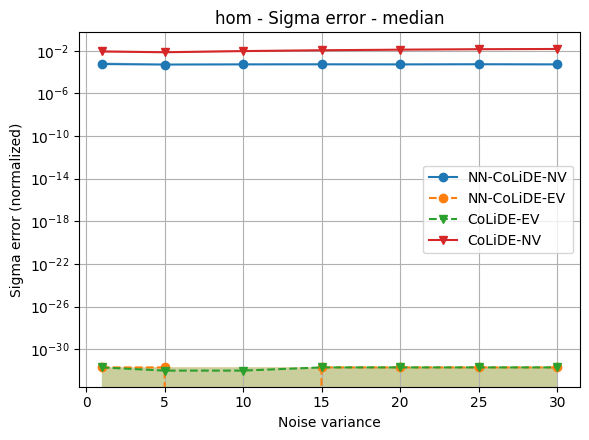

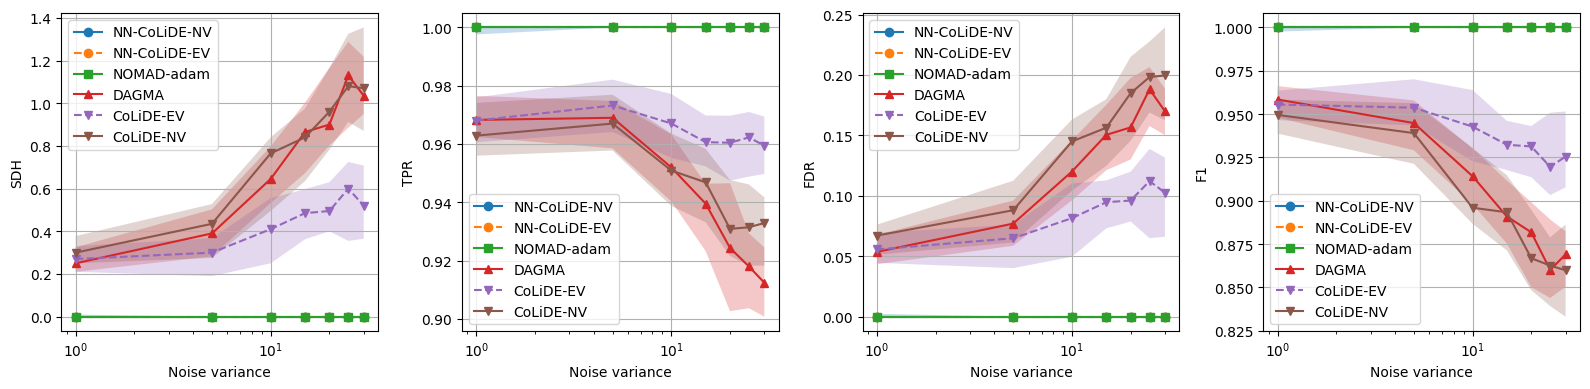

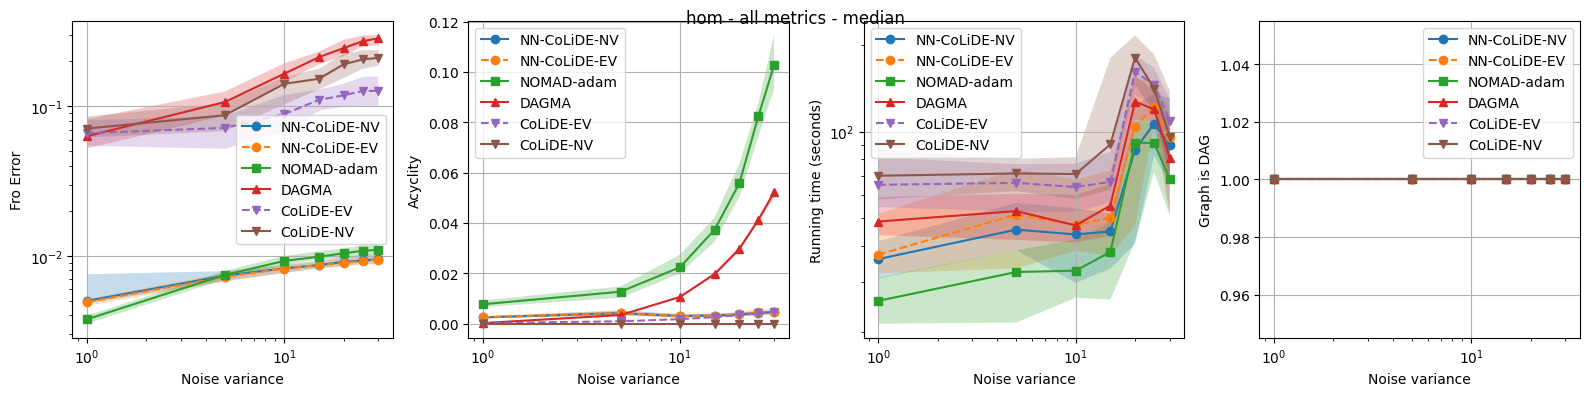


homoscedastic - normalized SHD (mean)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
variance,,,,,,
1,0.0054,0.0012,0.0004,0.2712,0.2776,0.3282
5,0.0010,0.0004,0.0002,0.4352,0.3160,0.4196
10,0.0008,0.0008,0.0012,0.6692,0.4088,0.6876
15,0.0008,0.0006,0.0020,0.8472,0.4880,0.8268
20,0.0008,0.0002,0.0008,1.0024,0.5264,1.0178
25,0.0014,0.0006,0.0038,1.1208,0.5650,1.1262
30,0.0016,0.0010,0.0018,1.0706,0.5490,1.1006



homoscedastic - Fro error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
variance,,,,,,
1,0.0050,0.0049,0.0038,0.0632,0.0663,0.0711
5,0.0074,0.0072,0.0075,0.1071,0.0719,0.0873
10,0.0082,0.0082,0.0092,0.1658,0.0888,0.1417
15,0.0087,0.0087,0.0099,0.2137,0.1108,0.1533
20,0.0091,0.0089,0.0104,0.2459,0.1186,0.1914
25,0.0093,0.0093,0.0108,0.2735,0.1271,0.2066
30,0.0095,0.0094,0.0110,0.2858,0.1273,0.2113



homoscedastic - Sigma error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
variance,,,,,,
1,0.0006,0.0,NaN,NaN,0.0,0.0087
5,0.0005,0.0,NaN,NaN,0.0,0.0074
10,0.0005,0.0,NaN,NaN,0.0,0.0095
15,0.0005,0.0,NaN,NaN,0.0,0.0114
20,0.0005,0.0,NaN,NaN,0.0,0.0129
25,0.0006,0.0,NaN,NaN,0.0,0.0142
30,0.0005,0.0,NaN,NaN,0.0,0.0150



homoscedastic - time (mean, s)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
variance,,,,,,
1,34.9507,39.2795,26.2267,50.2691,67.6227,71.4030
5,49.3917,53.5720,31.8038,51.1378,65.3305,70.6561
10,44.9260,51.6833,35.0848,50.4023,65.5417,70.1008
15,46.0555,59.2332,40.8303,65.3998,90.9310,121.0864
20,92.2601,106.9012,84.2625,126.7989,160.4229,183.4208
25,114.3733,128.0155,91.5854,120.2621,146.1434,148.5022
30,101.8674,99.6126,70.1529,83.1159,101.7004,105.2683


In [6]:
skip_idx = SKIP_IDX
hom_result = show_scenario(hom_scenario, skip_idx=skip_idx)

## Heteroscedastic scenario

[2026-09-15T09:23:36 pid=57112] Loaded variance results from /home/srey/Investigacion/nonneg_dag_learning/nomad/results/nonneg_colide/var/var_hetero_ERgraph_4N.npz


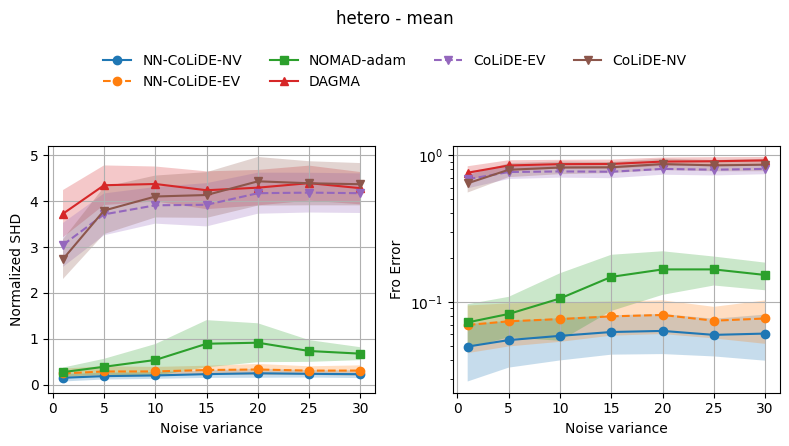

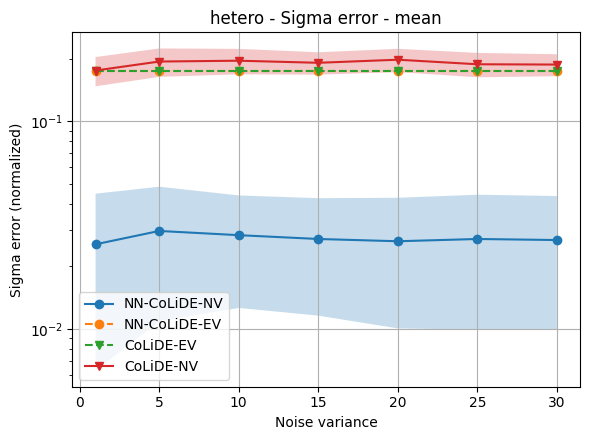

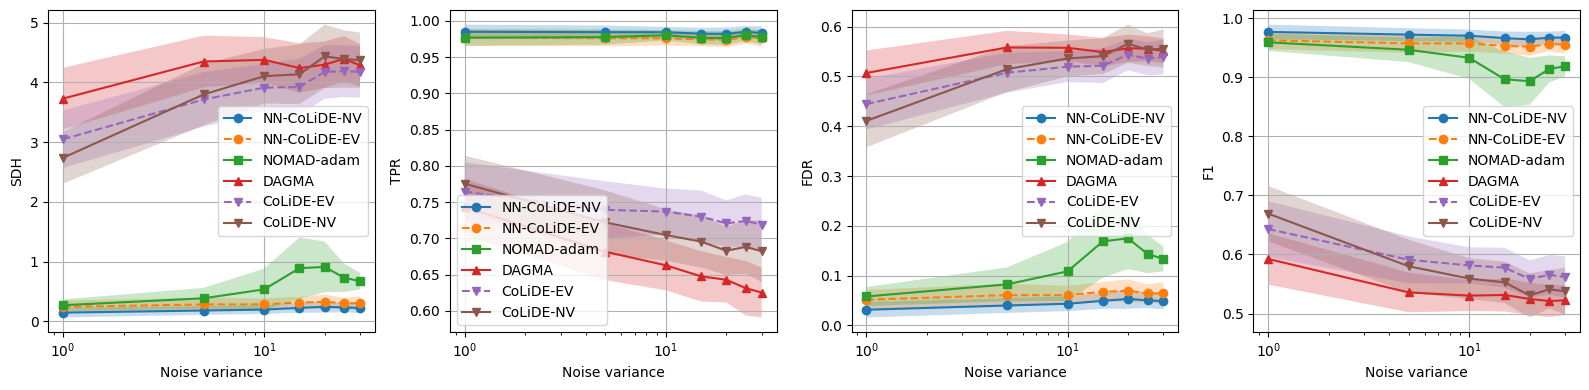

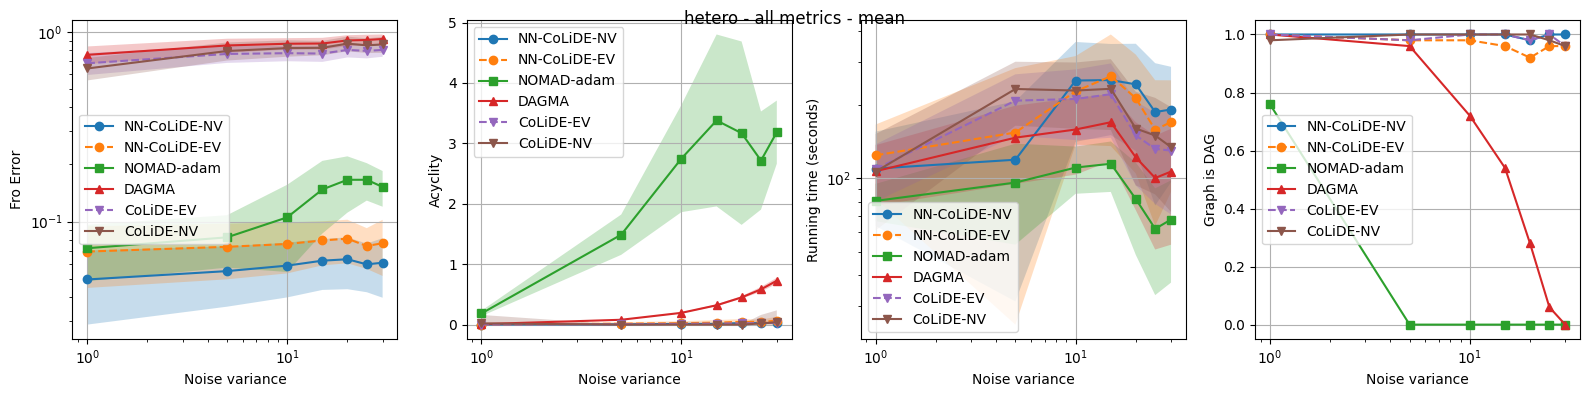

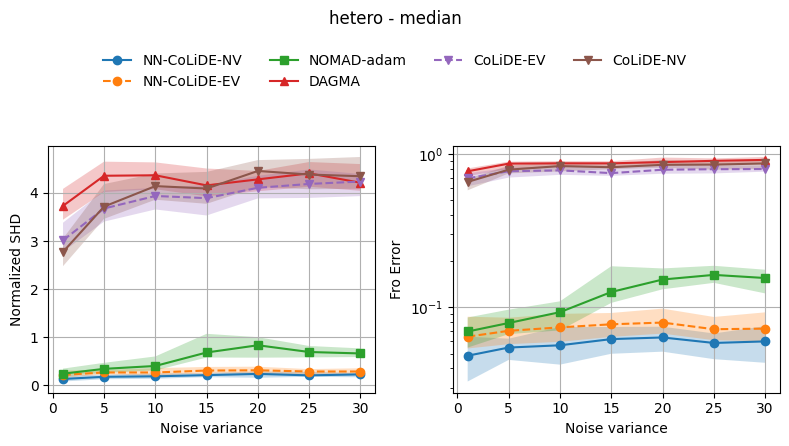

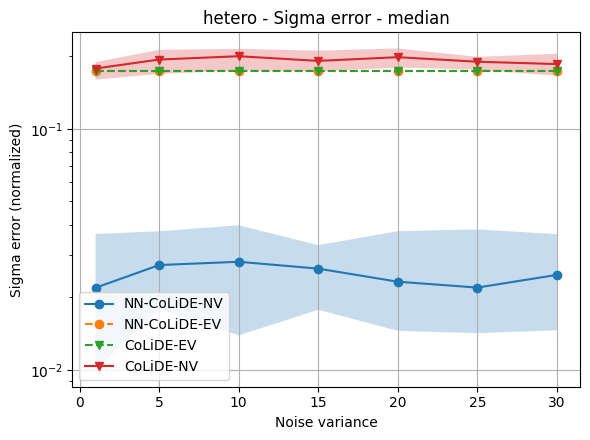

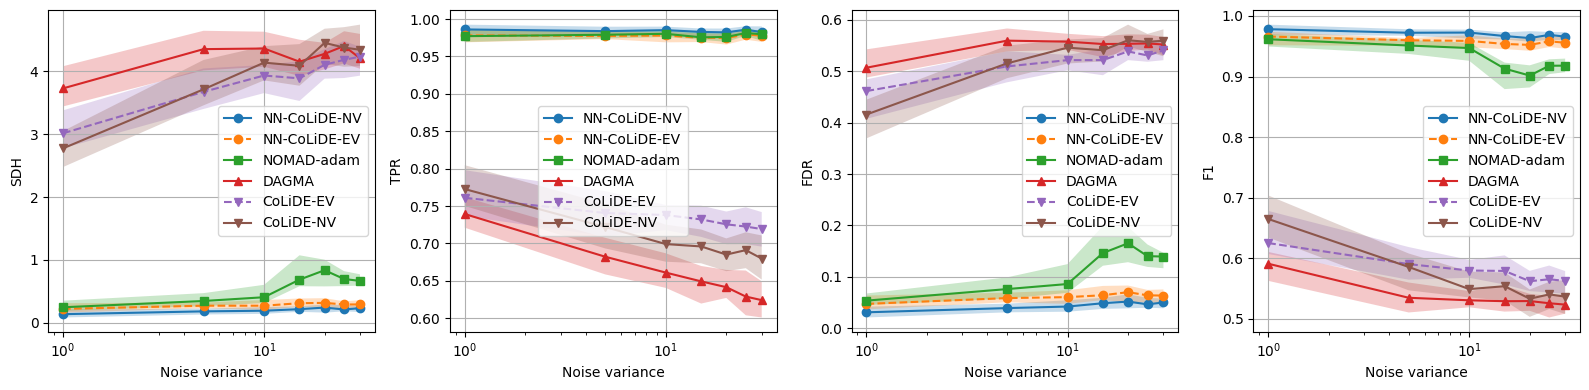

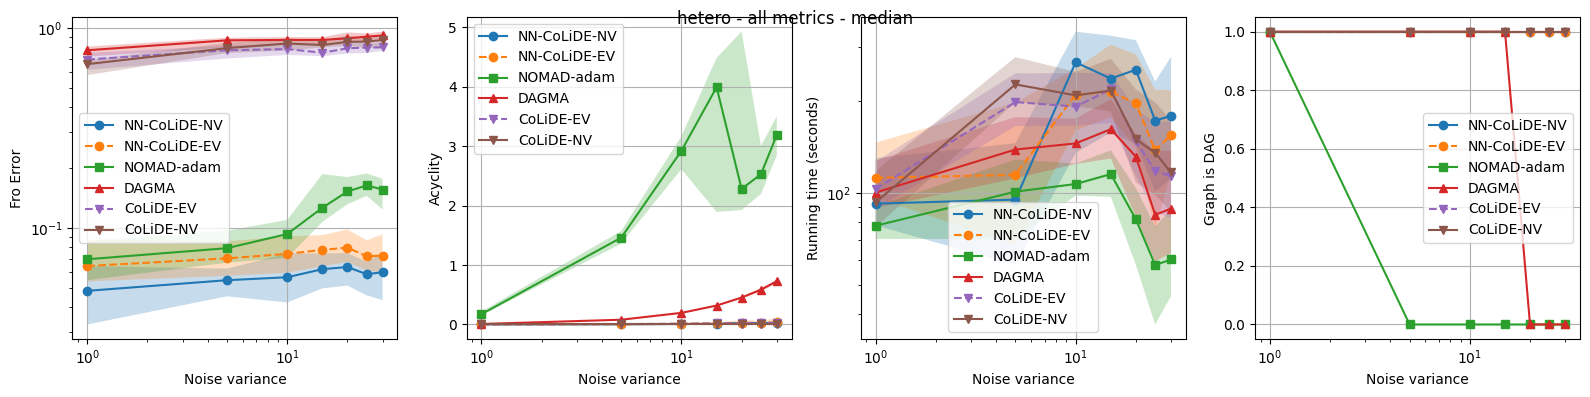


heteroscedastic - normalized SHD (mean)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
variance,,,,,,
1,0.1470,0.2424,0.2706,3.7274,3.0472,2.7368
5,0.1824,0.2840,0.3866,4.3480,3.7124,3.7962
10,0.1978,0.2852,0.5354,4.3754,3.9102,4.1022
15,0.2260,0.3162,0.8896,4.2386,3.9218,4.1348
20,0.2450,0.3276,0.9120,4.2952,4.1744,4.4338
25,0.2326,0.3028,0.7310,4.3940,4.1868,4.3912
30,0.2250,0.3044,0.6730,4.2836,4.1742,4.3702



heteroscedastic - Fro error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
variance,,,,,,
1,0.0484,0.0645,0.0697,0.7731,0.6949,0.6591
5,0.0547,0.0704,0.0791,0.8669,0.7734,0.7922
10,0.0566,0.0741,0.0931,0.8709,0.7837,0.8356
15,0.0621,0.0776,0.1261,0.8710,0.7517,0.8214
20,0.0637,0.0797,0.1521,0.8875,0.7911,0.8517
25,0.0586,0.0721,0.1630,0.9042,0.7973,0.8546
30,0.0600,0.0727,0.1555,0.9170,0.7995,0.8694



heteroscedastic - Sigma error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
variance,,,,,,
1,0.0219,0.1743,NaN,NaN,0.1743,0.1780
5,0.0272,0.1743,NaN,NaN,0.1743,0.1939
10,0.0281,0.1743,NaN,NaN,0.1743,0.2001
15,0.0263,0.1743,NaN,NaN,0.1743,0.1914
20,0.0232,0.1743,NaN,NaN,0.1743,0.1983
25,0.0219,0.1743,NaN,NaN,0.1743,0.1899
30,0.0248,0.1743,NaN,NaN,0.1743,0.1857



heteroscedastic - time (mean, s)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
variance,,,,,,
1,109.5283,124.2231,80.7756,106.8982,109.0155,106.5023
5,119.1637,154.0691,96.0299,146.7452,208.1556,232.4030
10,251.6883,227.2569,110.6479,158.5048,211.5165,229.0019
15,252.8681,262.1461,114.7173,169.7825,221.2075,232.7954
20,242.7560,213.0613,82.2197,121.7988,149.9472,159.9943
25,186.9130,158.1358,62.0551,100.2940,131.9784,149.7707
30,191.4540,170.0836,67.7236,106.5080,129.9115,134.2615


In [7]:
skip_idx = SKIP_IDX
hetero_result = show_scenario(hetero_scenario, skip_idx=skip_idx)

## Joint figures

Homoscedastic curves are drawn with solid lines and heteroscedastic ones with dashed lines.
`skip_idx` refers to method indices (printed above) and applies to both scenarios.

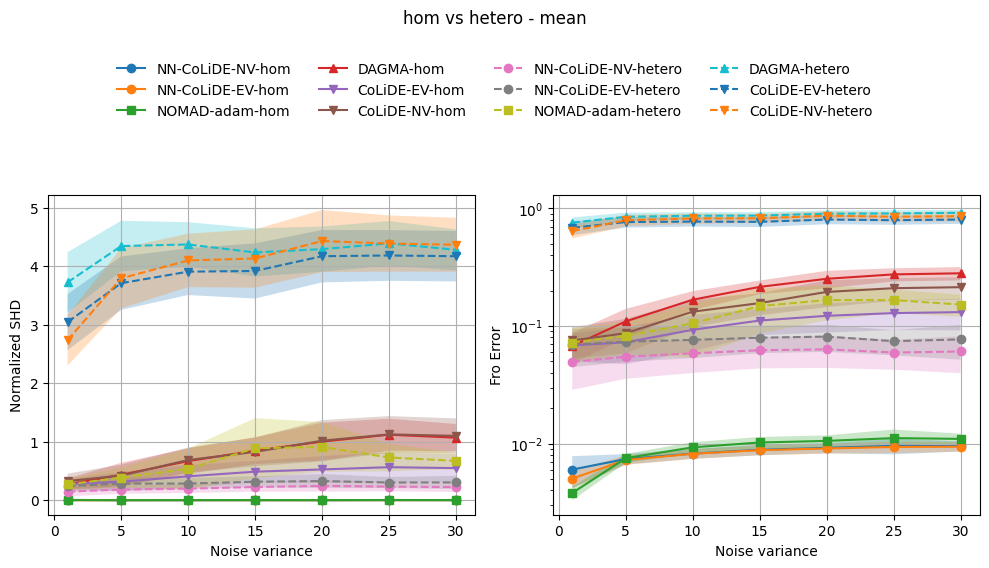

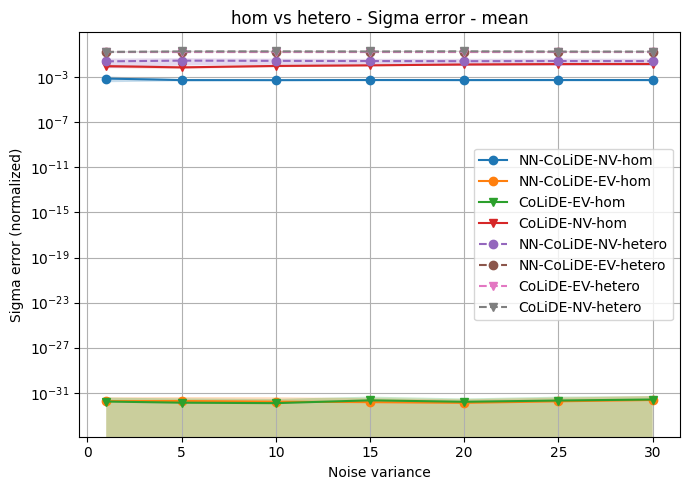

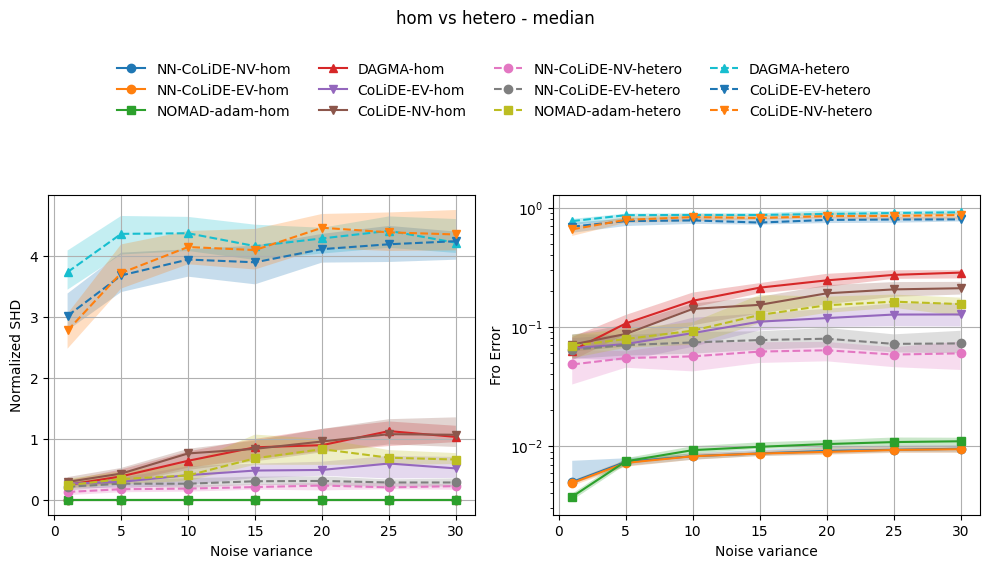

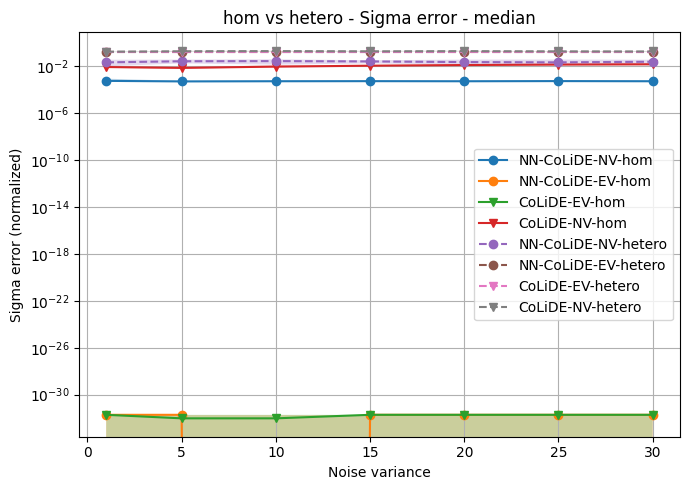

In [8]:
scenario_results = [hom_result, hetero_result]
skip_idx = SKIP_IDX

for agg in JOINT_AGGS:
    dv.plot_joint_results(scenario_results, agg=agg, skip_idx=skip_idx, save=SAVE_FIGS)
plt.show()